# Aquaplanet

This notebook demonstrates a JAX-ESM (JEM) example using JAX-GCM (JCM) and Slab Ocean Model as an aquaplanet.

In [1]:
from pathlib import Path

import jcm
from jcm.geometry import Geometry
import jax_datetime as jdt

from jem.components import JCM, SlabOceanModel
from jem.mapping import BasicMapper
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

## Configurations

In [2]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
output_dir = Path("output/JCM_SOM").resolve()
output_dir.mkdir(exist_ok=True, parents=True)
one_second = jdt.to_timedelta(1, "second")

## Creating Flux and Scalar Exchange between Components

In [3]:
mapper = BasicMapper()
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("ocn", "forcing.total_heat_flux"),
    regridder = lambda x: x,  # identity is default
)
mapper.add_mapping(
    source = ("ocn", "state.sea_surface_temperature"),
    target = ("atm", "forcing.sea_surface_temperature"),
)

## Create Components

In [4]:
atm_model = jcm.model.Model(
    start_date=start_datetime,
)

atm_model = JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
    land_model_active = False,
)

model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=SlabOceanModel(
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Notice: No mask_file given. Set fmask = 0.
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Model info: 
/Model
├── ● component_info <dict>
│   ├── ● atm <dict>
│   │   └── ○ diffusion <str>: DiffusionFilter(vor_q_timescale=43200, vor_q_order=2, temp_timescale=86400, temp_order=2, div_timescale=7200, div_order=1)
│   └── ● ocn <dict>
│       └── ○ relaxation_time

## Run Coupled Model

In [5]:
simulation_interval = jdt.to_timedelta(30, "day")
initial_state, final_state, predictions = model.run(
    workflow=["mapper", "atm", "ocn"],
    iterations = int(simulation_interval / coupling_timestep),
)

/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Boundary does not exist. Idealized initial SST will be used.
grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.
Flattened workflow:  mapper, atm, ocn
Doing: ocn.state.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> ocn.forcing.total_heat_flux
Using method: None


Simulation:   0%|          | 0/60 [00:00<?, ?it/s]

## Output into NetCDF

In [6]:
output_dict = model.predictions_to_xarray(predictions)
output_dict_subsample = {}
subsample_skip = 5
for component_name, ds in output_dict.items():
    output_file = output_dir / f"{component_name:s}.nc"
    print(f"Output file: {str(output_file)}, with subsample_skip = {subsample_skip:d}")
    ds = ds.isel(time=slice(None, None, subsample_skip))
    ds.to_netcdf(output_file, engine="netcdf4")
    output_dict_subsample[component_name] = ds

Output file: /home/xtt/projects/project_jax-esm/jax-esm_repo/docs/notebooks/01_basic/output/JCM_SOM/atm.nc, with subsample_skip = 5
Output file: /home/xtt/projects/project_jax-esm/jax-esm_repo/docs/notebooks/01_basic/output/JCM_SOM/ocn.nc, with subsample_skip = 5


## Visualization

In [7]:
import matplotlib.pyplot as plt

### Atmosphere

In [8]:
ds = output_dict_subsample["atm"]
print(str(ds))

<xarray.Dataset> Size: 44MB
Dimensions:                          (time: 12, lon: 96, lat: 48, level: 8)
Coordinates:
  * time                             (time) datetime64[ns] 96B 2000-01-01 ......
  * lon                              (lon) float64 768B 0.0 3.75 ... 352.5 356.2
  * lat                              (lat) float64 384B -87.16 -83.48 ... 87.16
  * level                            (level) float32 32B 0.95 0.835 ... 0.025
Data variables: (12/79)
    surface_flux.rlus.1              (time, lon, lat) float32 221kB ...
    mod_radcon.flux.3                (time, lon, lat) float32 221kB ...
    condensation.precls              (time, lon, lat) float32 221kB ...
    date.dt_seconds                  (time) float32 48B ...
    surface_flux.ustr.0              (time, lon, lat) float32 221kB ...
    surface_flux.v0                  (time, lon, lat) float32 221kB ...
    ...                               ...
    surface_flux.u0                  (time, lon, lat) float32 221kB ...
    s

#### Precipitation

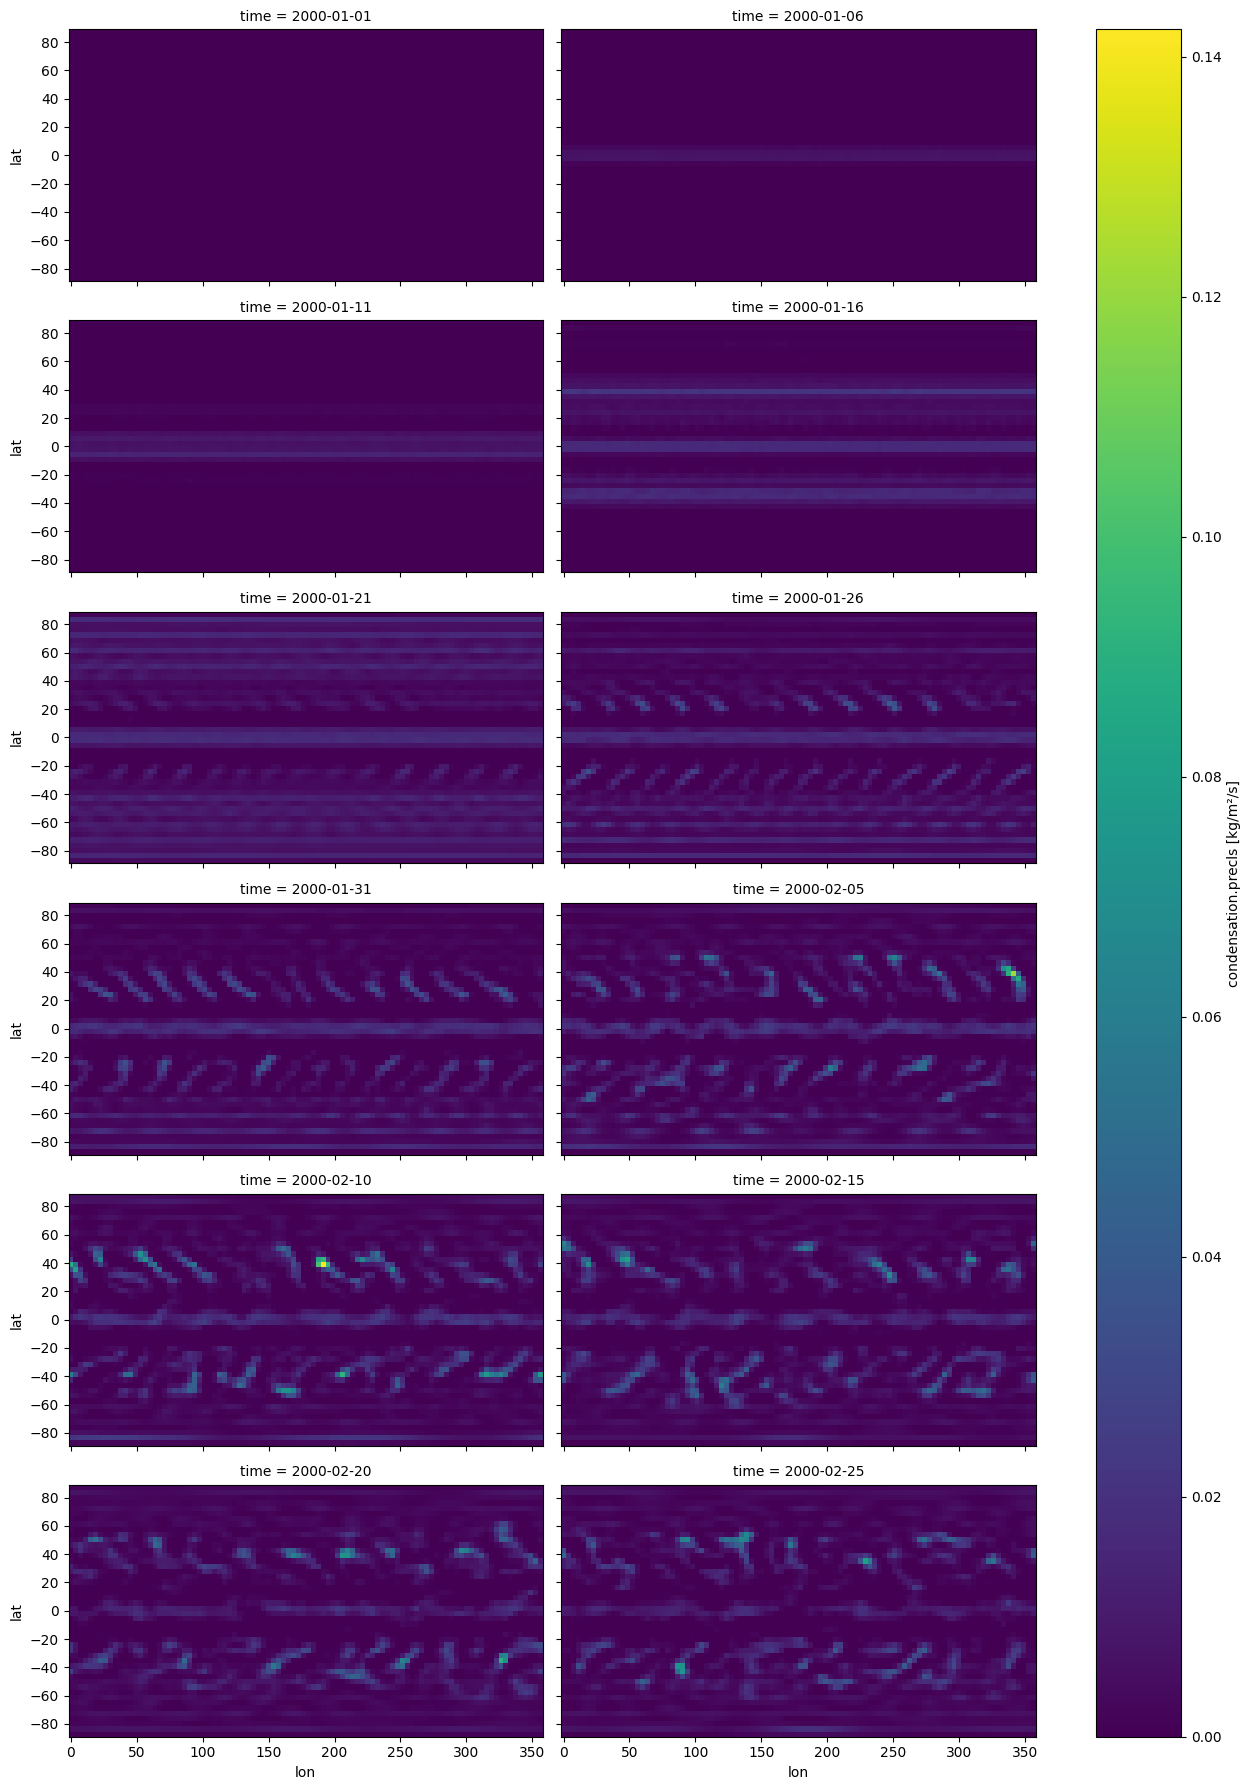

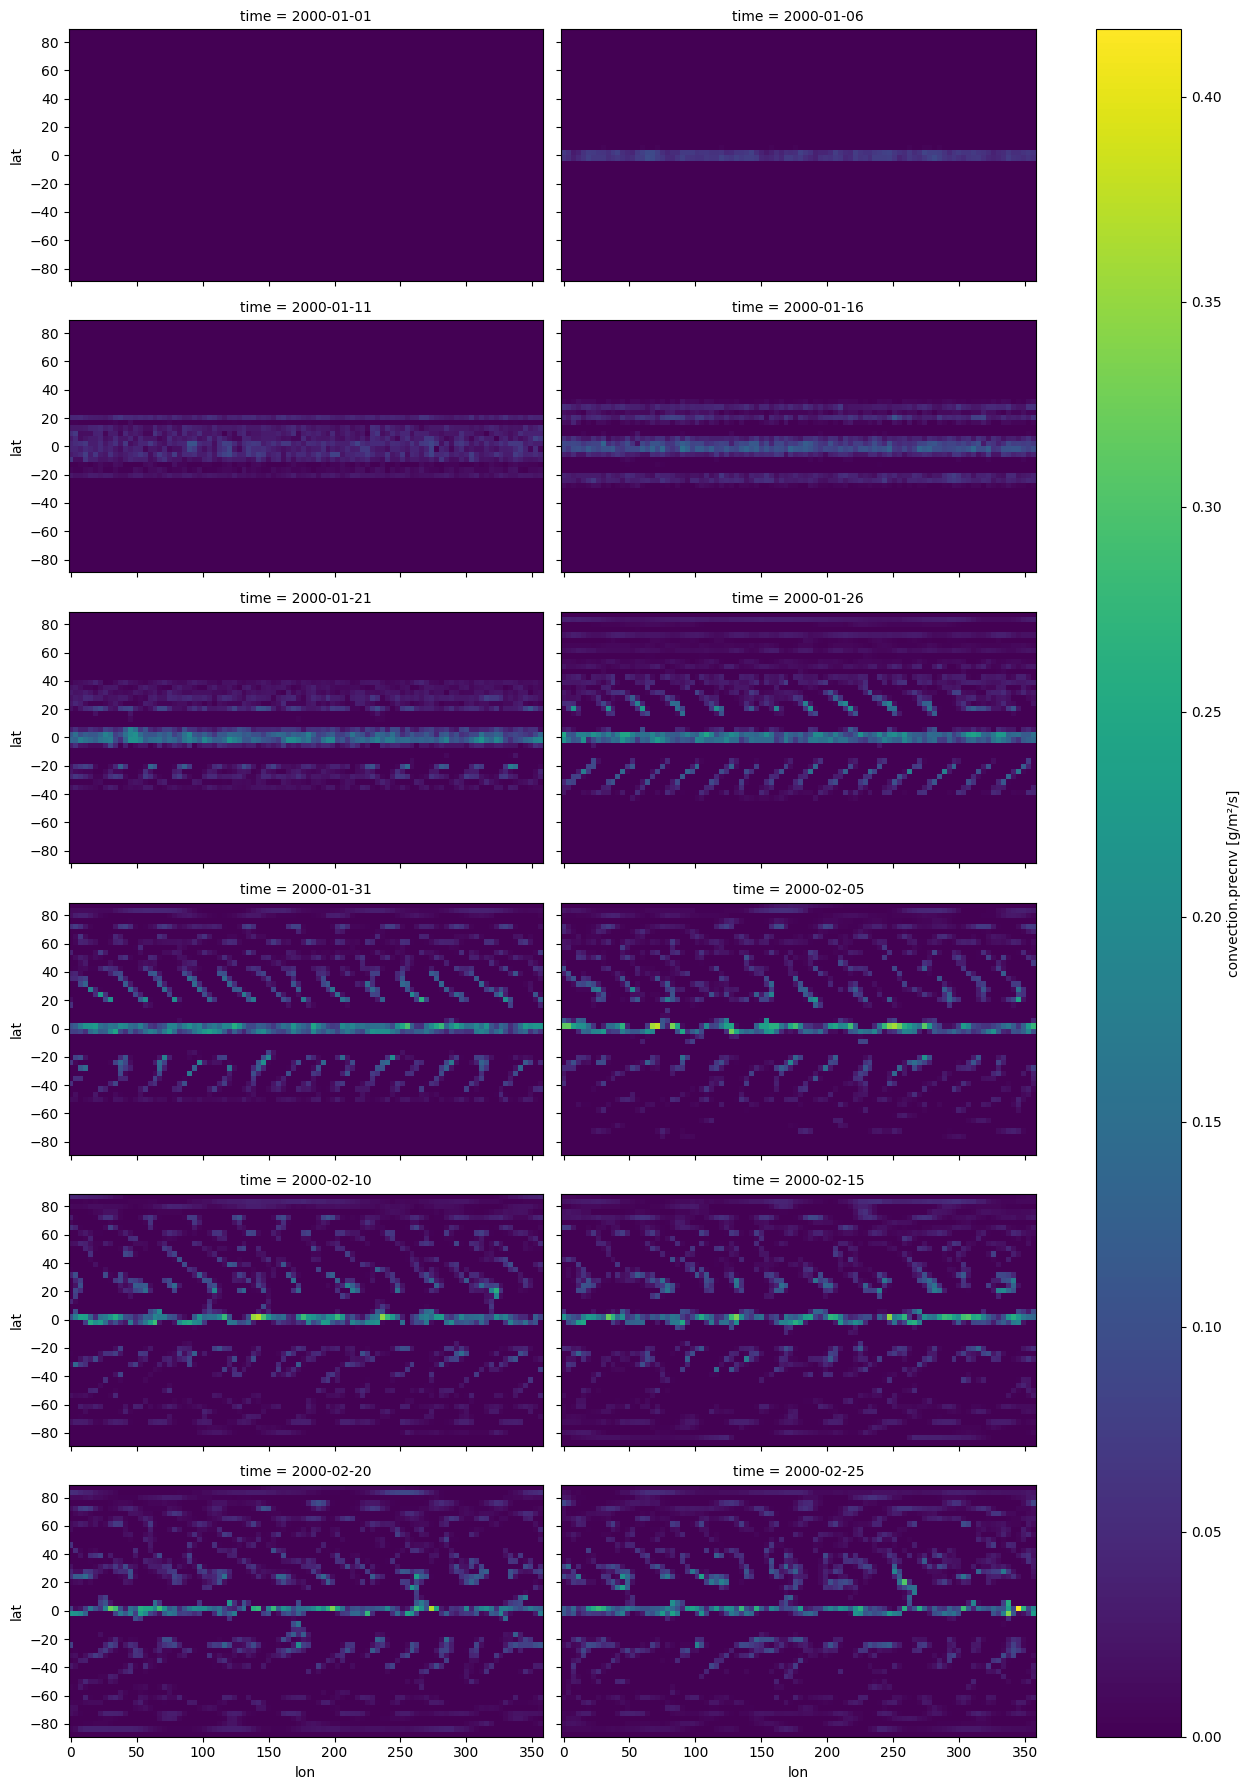

In [9]:
ds['condensation.precls'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)
ds['convection.precnv'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)

#### Moisture

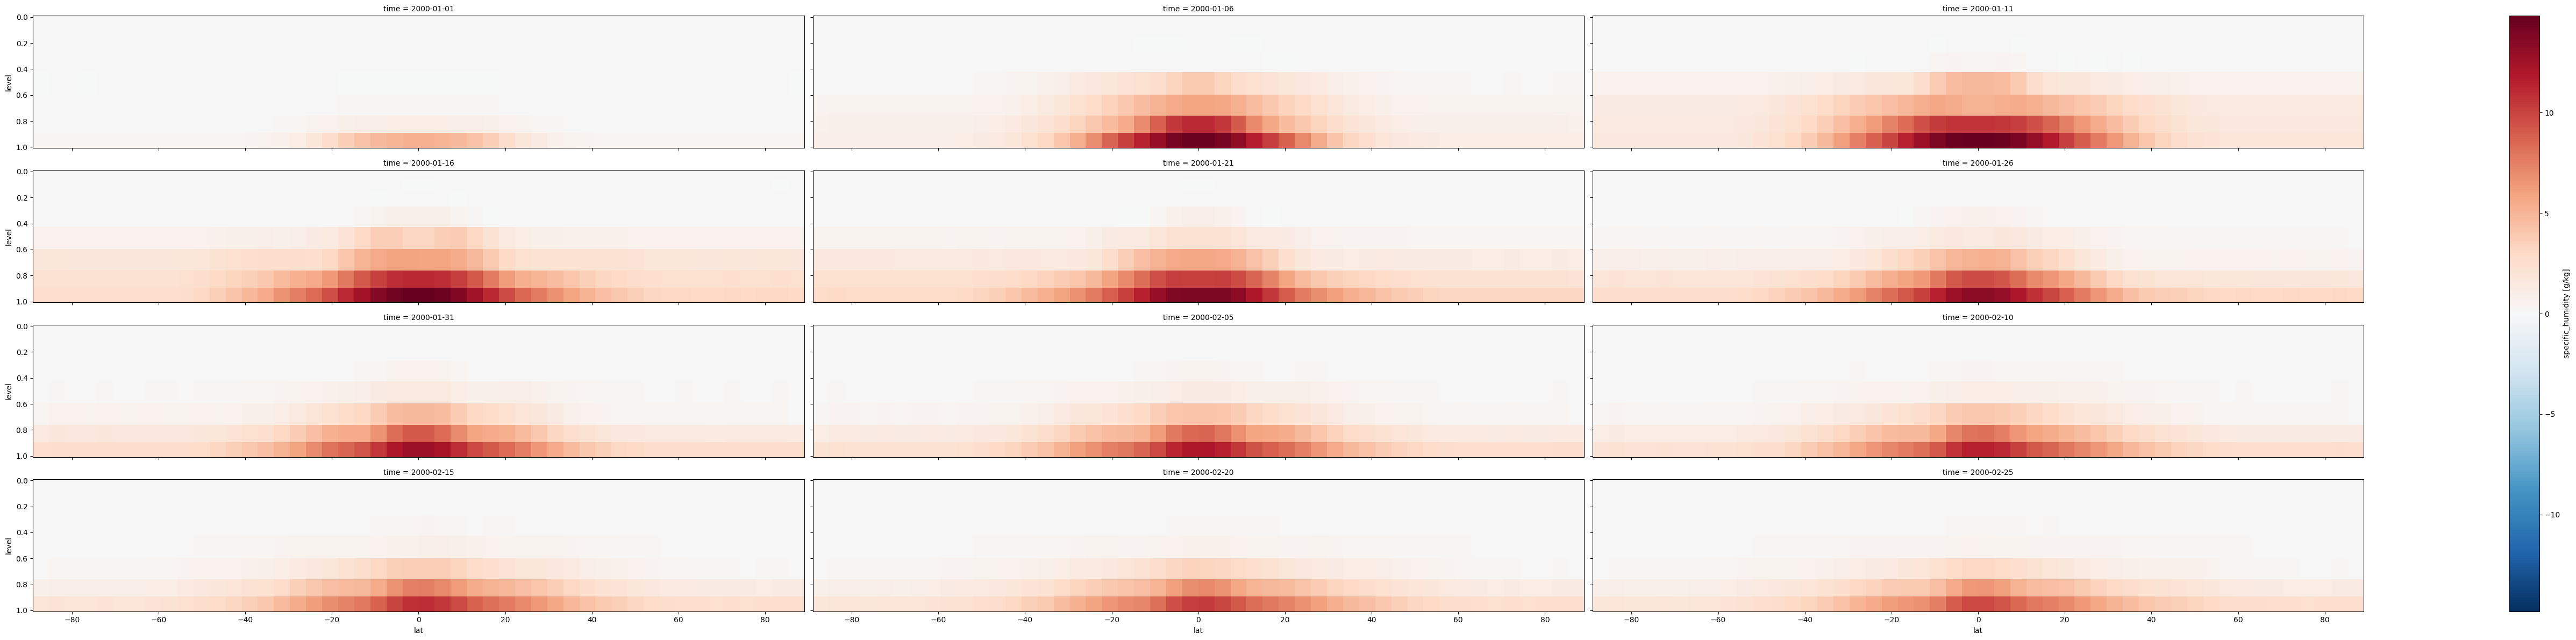

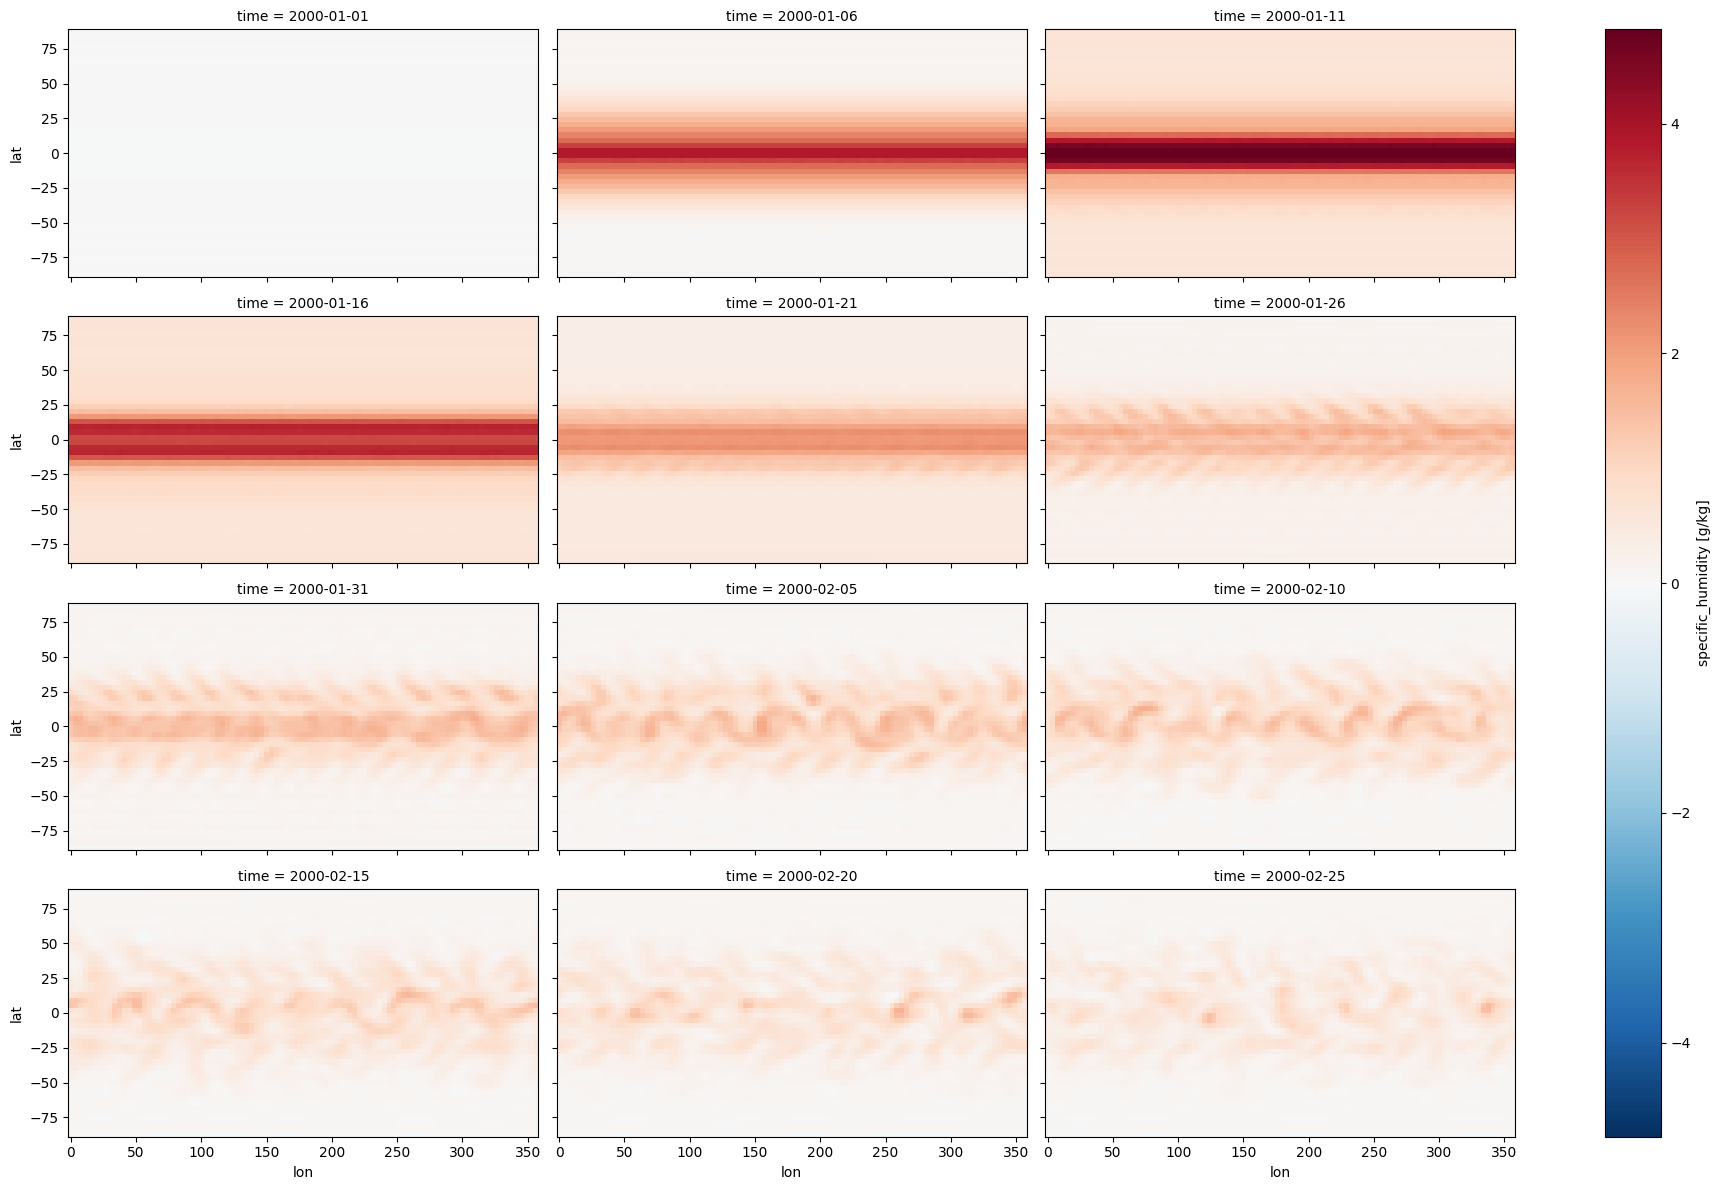

In [10]:
ds['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
ds['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

#### Clouds

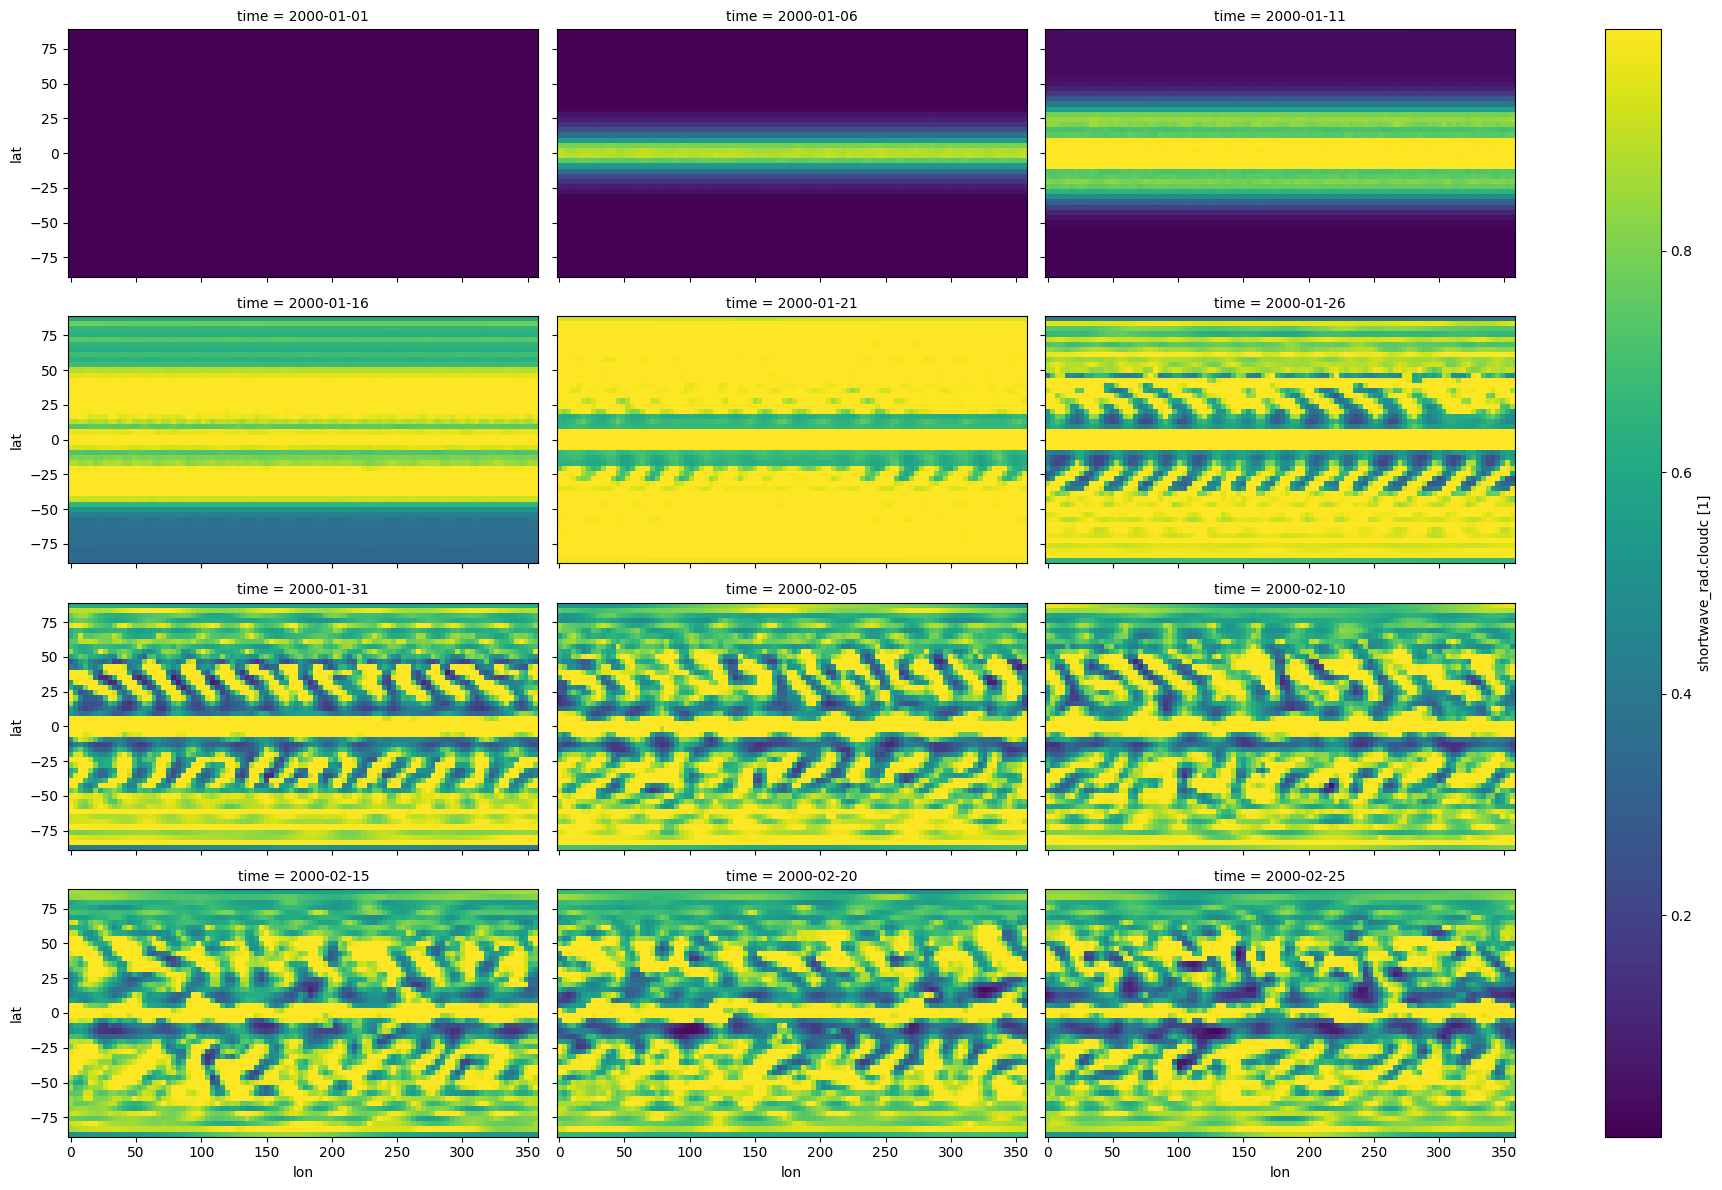

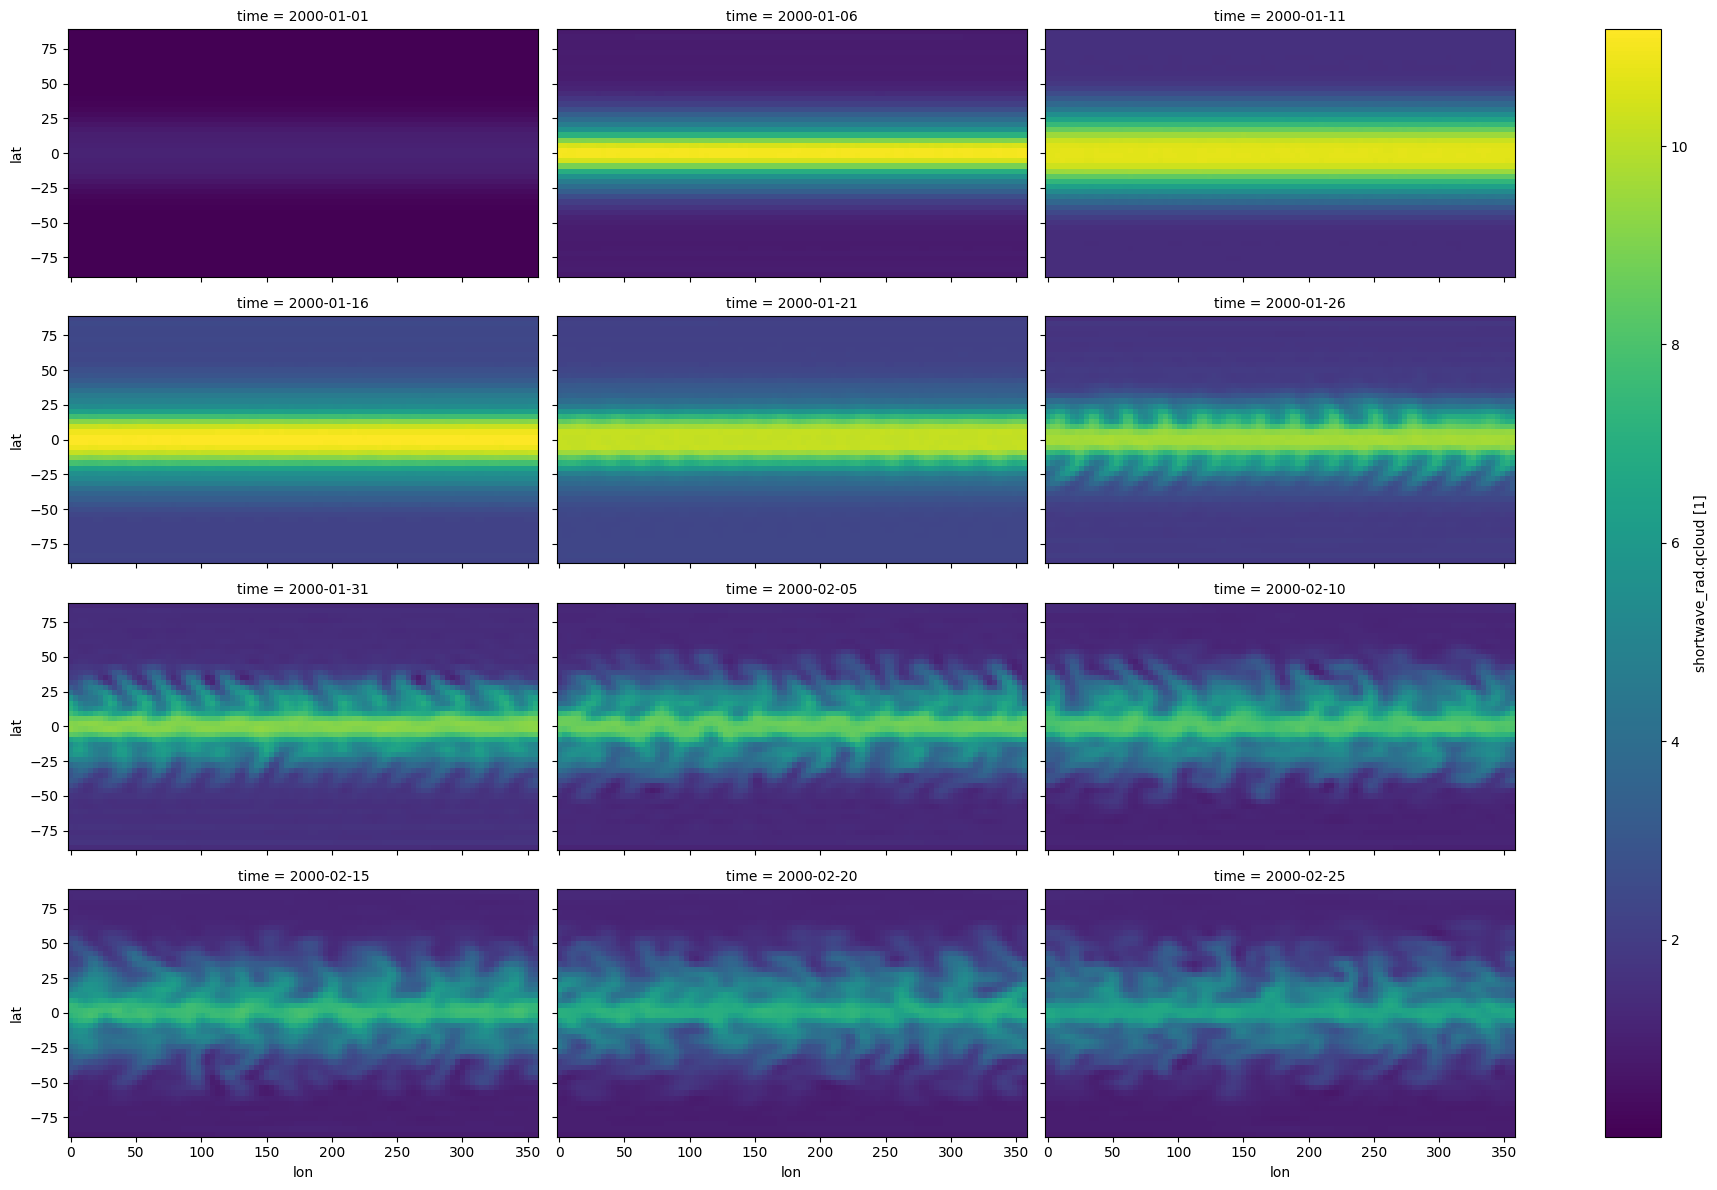

In [11]:
ds['shortwave_rad.cloudc'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
ds['shortwave_rad.qcloud'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

### Ocean

In [12]:
ds = output_dict_subsample["ocn"]
print(str(ds))

<xarray.Dataset> Size: 700kB
Dimensions:                  (time: 12, longitude: 96, latitude: 48)
Coordinates:
  * time                     (time) float32 48B 24.0 144.0 ... 1.344e+03
    latitude2D               (longitude, latitude) float32 18kB ...
    longitude2D              (longitude, latitude) float32 18kB ...
Dimensions without coordinates: longitude, latitude
Data variables:
    sea_surface_temperature  (time, longitude, latitude) float32 221kB ...
    mixed_layer_depth        (time, longitude, latitude) float32 221kB ...
    total_heat_flux          (time, longitude, latitude) float32 221kB ...


#### Sea Surface Temperature
We plot both the SST and its difference with respect to the initial condition.

Text(0.5, 0.98, 'Sea Surface Temperature [${}^\\circ \\mathrm{C}$]')

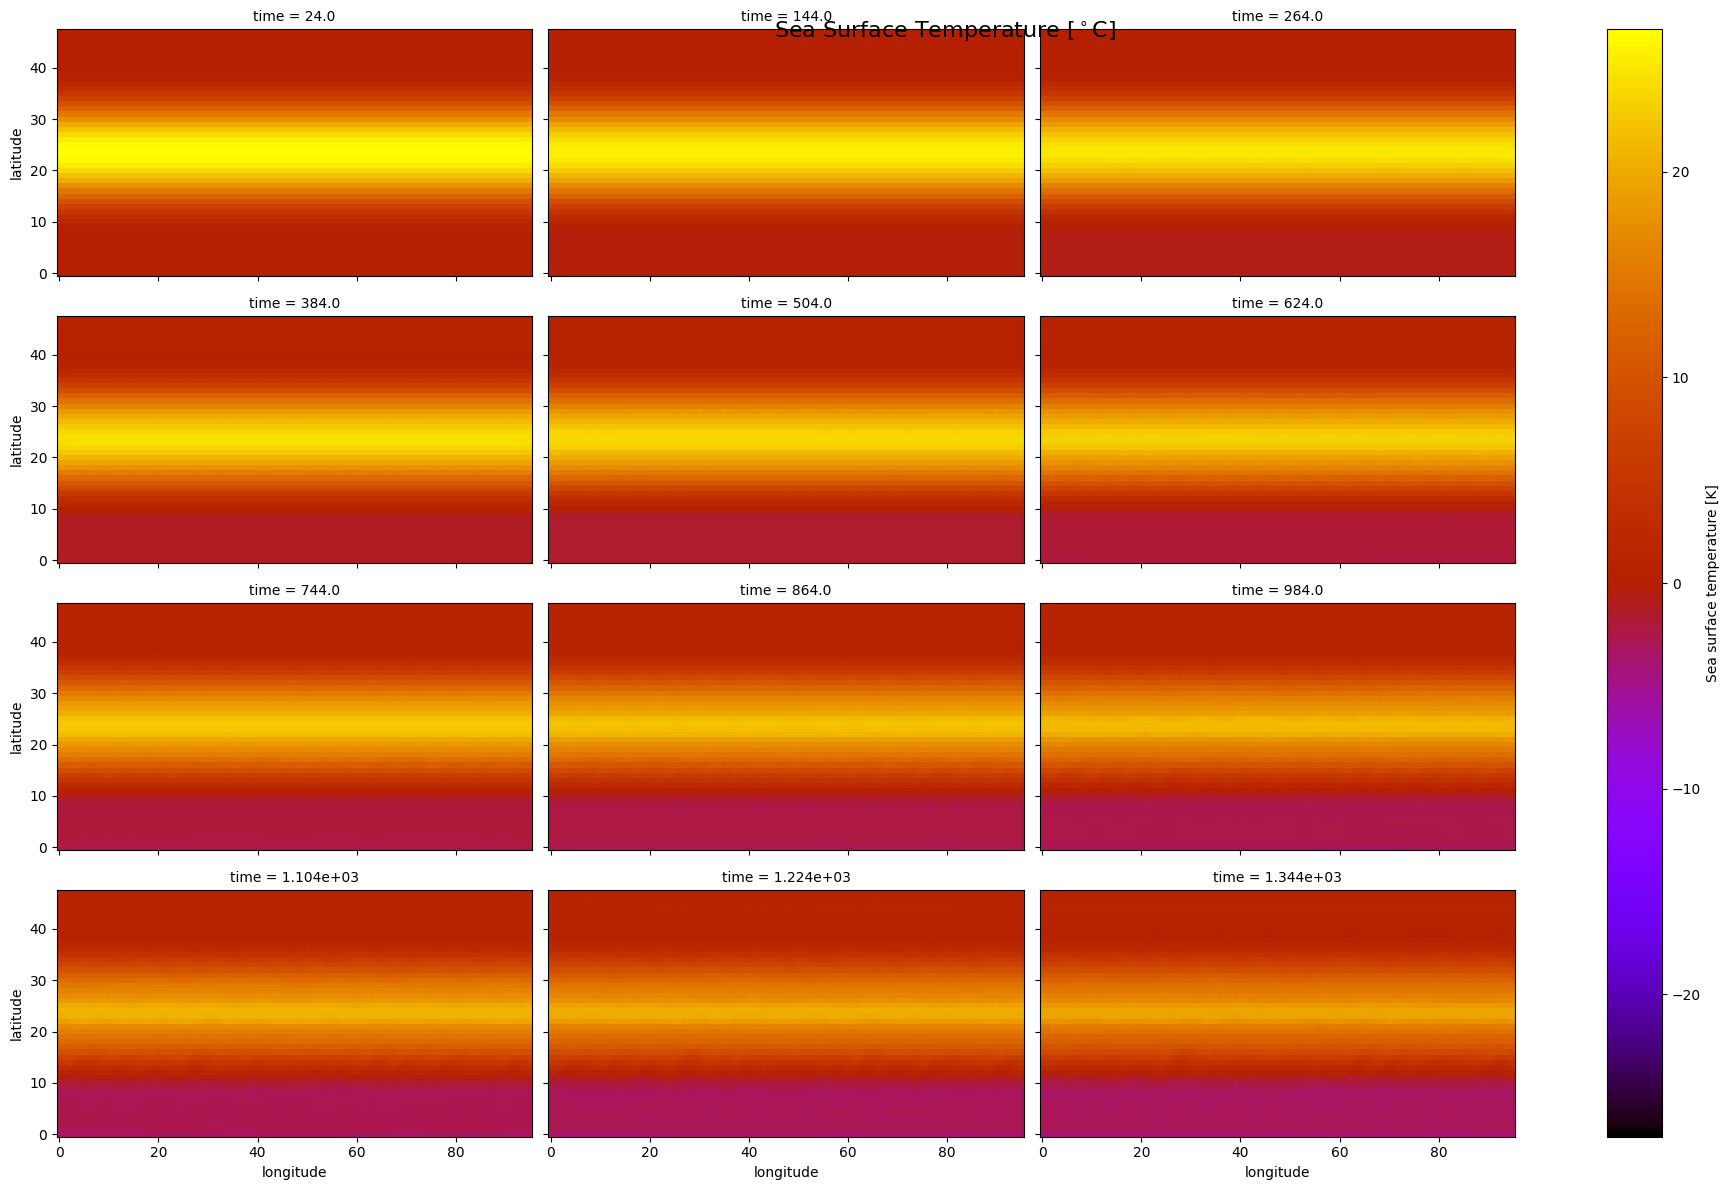

In [13]:
g = (ds['sea_surface_temperature'] - 273.15).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="gnuplot")
g.fig.suptitle("Sea Surface Temperature [${}^\\circ \\mathrm{C}$]", fontsize=16)

Text(0.5, 0.98, 'Difference of Sea Surface Temperature between labeled time and initial condition [${}^\\circ \\mathrm{C}$]')

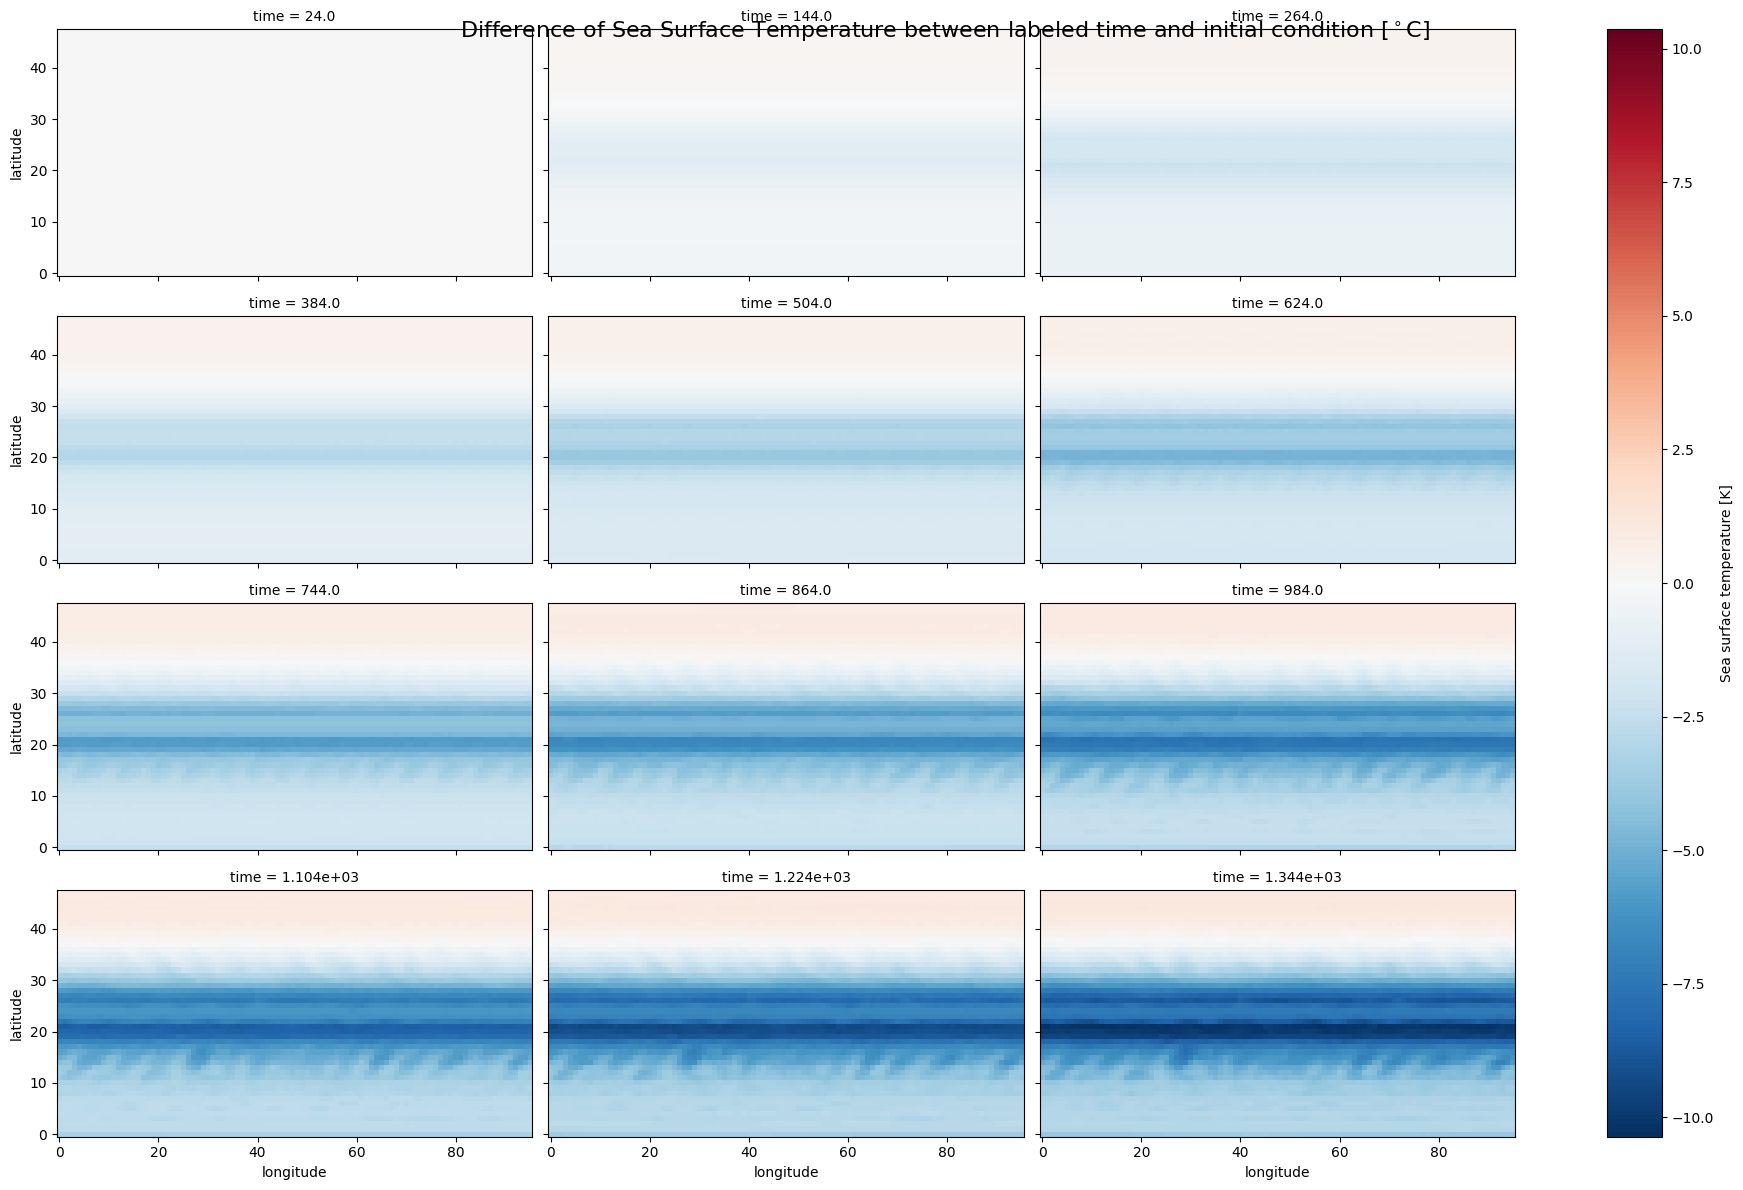

In [14]:
g = (ds['sea_surface_temperature'] - ds['sea_surface_temperature'].isel(time=0)).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, center=0)
g.fig.suptitle("Difference of Sea Surface Temperature between labeled time and initial condition [${}^\\circ \\mathrm{C}$]", fontsize=16)

#### Total heat flux

Text(0.5, 0.98, 'Total heat flux (upward positive) [$\\mathrm{W} / \\mathrm{m}^2$]')

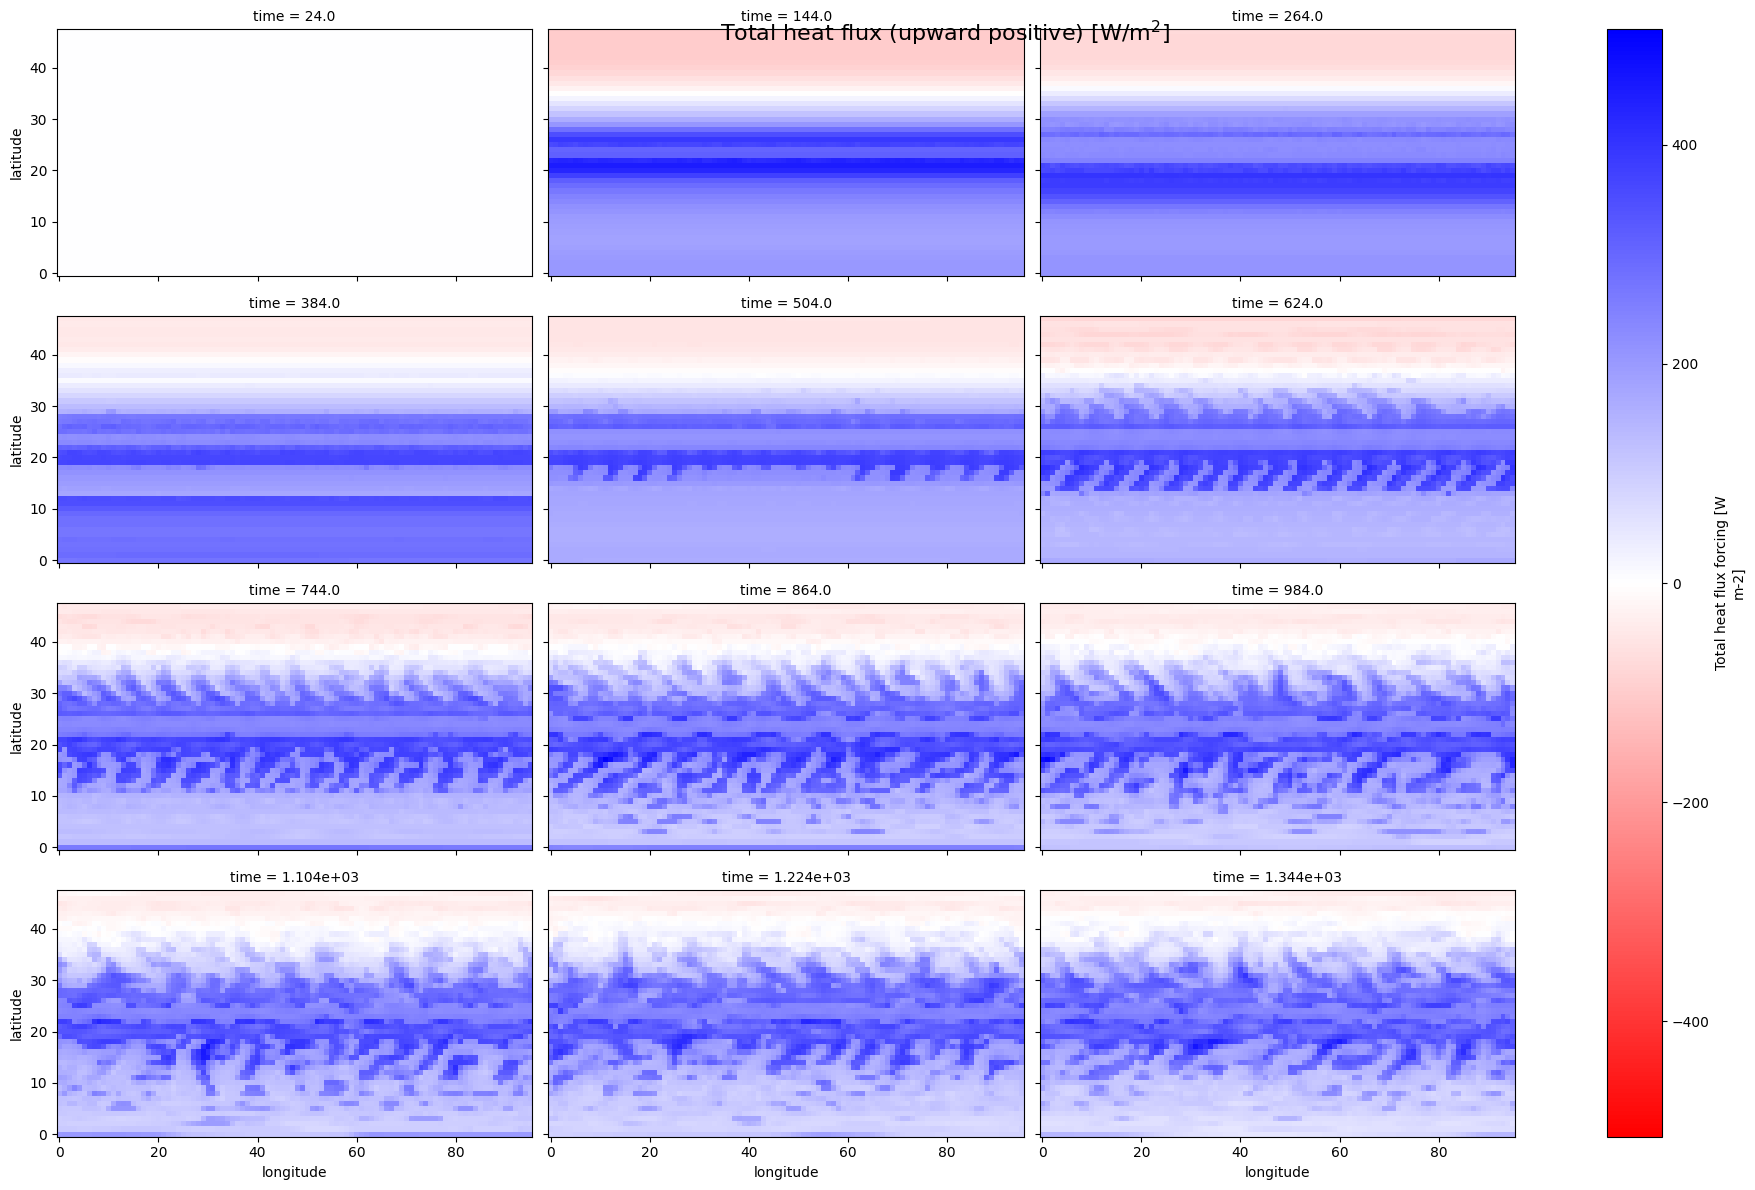

In [15]:
g = ds['total_heat_flux'].plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="bwr_r", center=0.0)
g.fig.suptitle("Total heat flux (upward positive) [$\\mathrm{W} / \\mathrm{m}^2$]", fontsize=16)

In [16]:
plt.show()

## Making animation of specific humidity of the surface grid

Plotting frame=0
Plotting frame=0
Plotting frame=1
Plotting frame=2
Plotting frame=3
Plotting frame=4
Plotting frame=5
Plotting frame=6
Plotting frame=7
Plotting frame=8
Plotting frame=9
Plotting frame=10
Plotting frame=11
Plotting frame=12
Plotting frame=13
Plotting frame=14
Plotting frame=15
Plotting frame=16
Plotting frame=17
Plotting frame=18
Plotting frame=19
Plotting frame=20
Plotting frame=21
Plotting frame=22
Plotting frame=23
Plotting frame=24
Plotting frame=25
Plotting frame=26
Plotting frame=27
Plotting frame=28
Plotting frame=29
Plotting frame=30
Plotting frame=31
Plotting frame=32
Plotting frame=33
Plotting frame=34
Plotting frame=35
Plotting frame=36
Plotting frame=37
Plotting frame=38
Plotting frame=39
Plotting frame=40
Plotting frame=41
Plotting frame=42
Plotting frame=43
Plotting frame=44
Plotting frame=45
Plotting frame=46
Plotting frame=47
Plotting frame=48
Plotting frame=49
Plotting frame=50
Plotting frame=51
Plotting frame=52
Plotting frame=53
Plotting frame=54
Plo

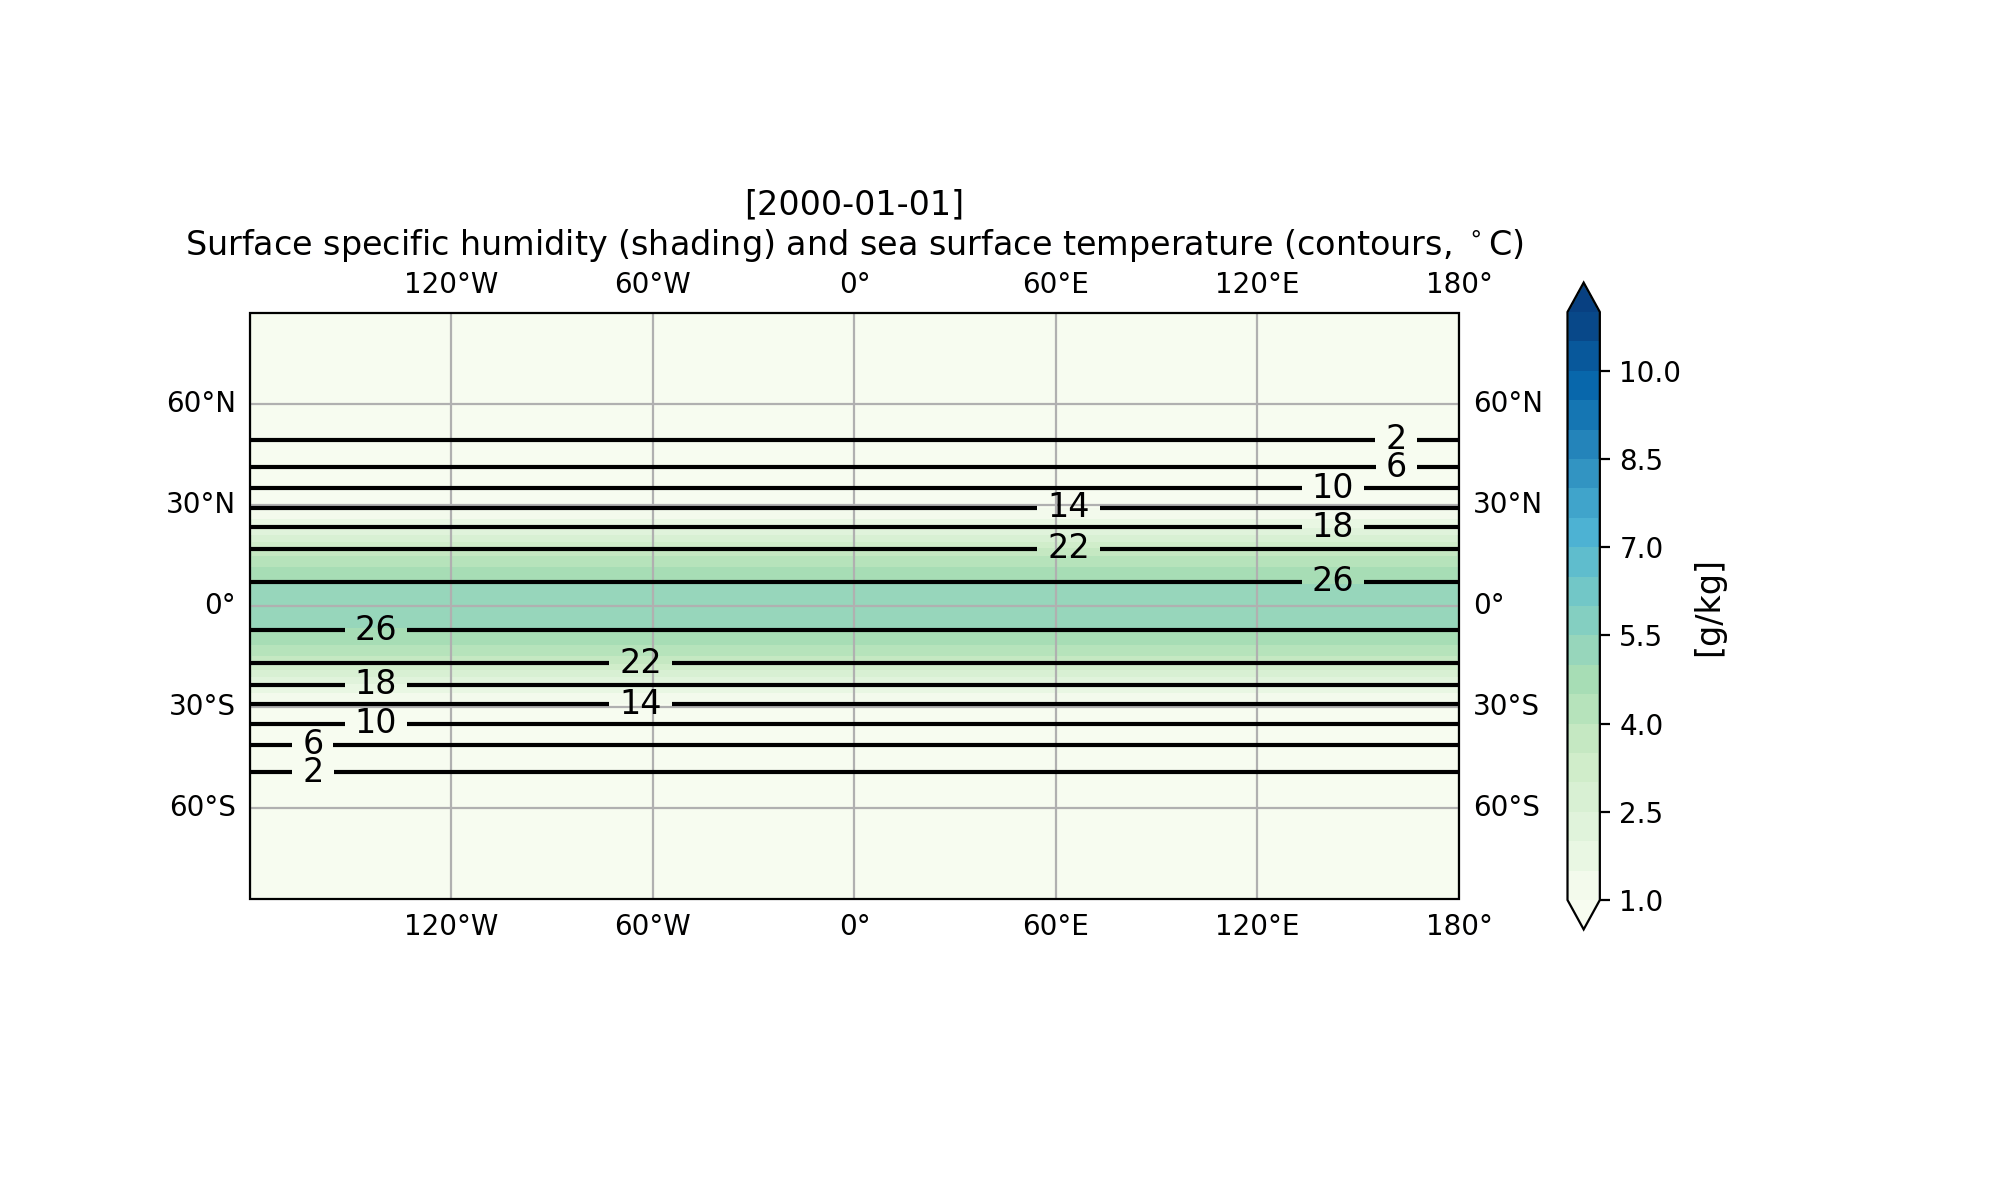

Plotting frame=0


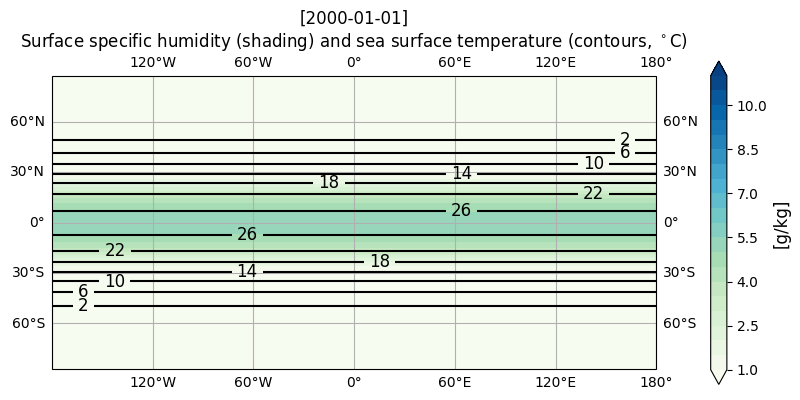

In [17]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import numpy as np

output_dict_animation = {
    component_name: _ds.isel(time=slice(None, None, 1))
    for component_name, _ds in output_dict.items()
}

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.gridlines(draw_labels=True)
cb = None
cf = None
cs = None

def update(frame):
    print(f"Plotting frame={frame:d}")
    global cf, cb, cs 
    _data_q = output_dict_animation["atm"]["specific_humidity"].isel(time=frame, level=0)
    _data_sst = output_dict_animation["ocn"]["sea_surface_temperature"].isel(time=frame) - 273.15
    coords = _data_q.coords
    time_str = _data_q['time'].dt.strftime('%Y-%m-%d').to_numpy().item()
    lat = coords["lat"]
    lon = coords["lon"]

    # Remove contour and contourf if not empty
    cf and cf.remove()
    cs and cs.remove()
    
    # Plot the humidity field for the current time step
    cyclic_data_q, cyclic_lon = add_cyclic_point(_data_q.to_numpy().transpose(), coord=lon)
    mappable = ax.contourf(
        cyclic_lon, lat,
        cyclic_data_q,
        levels=1 + np.linspace(0, 1, 21) * 10,
        transform=ccrs.PlateCarree(), 
        cmap='GnBu',
        extend="both",
    )
    
    cyclic_data_sst, cyclic_lon = add_cyclic_point(_data_sst.to_numpy().transpose(), coord=lon)
    cs = ax.contour(
        cyclic_lon, lat,
        cyclic_data_sst,
        levels=np.arange(-2, 31, 4),
        transform=ccrs.PlateCarree(),
        colors="black",
    )
    ax.clabel(cs, fontsize=12)
    ax.set_title(f"[{time_str:s}]\nSurface specific humidity (shading) and sea surface temperature (contours, ${{}}^\\circ \\mathrm{{C}}$)")
    if cb is None:
        cb = plt.colorbar(ax=ax, mappable=mappable, orientation='vertical', shrink=0.7, pad=0.07)
        cb.set_label("[g/kg]", fontsize=12)
    
    return [cf,]
    
# Generate and save
ani = FuncAnimation(fig, update, frames=len(output_dict_animation["atm"].coords["time"]), interval=120, blit=False)
ani.save('humidity_map.gif', writer='pillow', dpi=200)
display(Image('humidity_map.gif'))